In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

os.listdir()

['.config', 'PlantVillage.zip', 'sample_data']

In [ ]:
import zipfile

zip_path = "/content/PlantVillage.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

dataset_path = "/content/PlantVillage"

print("Classes:", len(os.listdir(dataset_path)))
print(os.listdir(dataset_path)[:5])

Classes: 2
['train', 'val']


In [ ]:
train_path = "/content/PlantVillage/train"
val_path = "/content/PlantVillage/val"

In [ ]:
import os

classes = os.listdir(train_path)

print("Number of Classes:", len(classes))
print("\nSample Classes:\n")

for cls in classes[:10]:
    print(cls)

Number of Classes: 38

Sample Classes:

Grape___Esca_(Black_Measles)
Tomato___Late_blight
Potato___Early_blight
Apple___healthy
Potato___Late_blight
Pepper,_bell___healthy
Apple___Black_rot
Raspberry___healthy
Blueberry___healthy
Tomato___healthy


In [ ]:
total_train = 0
total_val = 0

for cls in classes:
    class_path = os.path.join(train_path, cls)
    total_train += len(os.listdir(class_path))

print("Total Training Images:", total_train)

for cls in classes:
    class_path1 = os.path.join(val_path, cls)
    total_val += len(os.listdir(class_path1))

print("Total Validation Images:", total_val)

Total Training Images: 43444
Total Validation Images: 10861


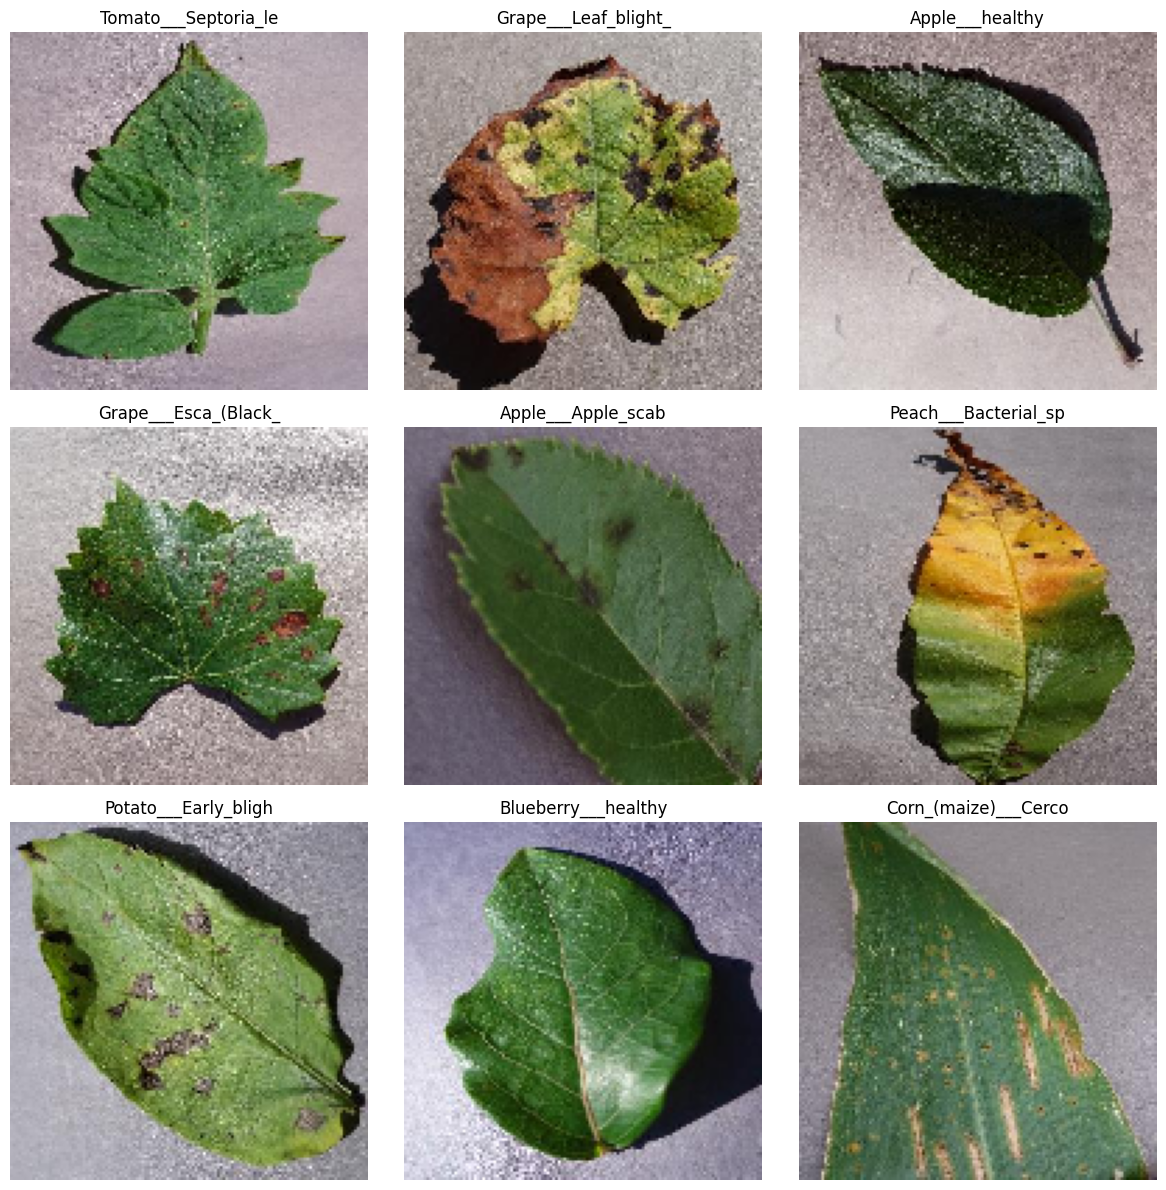

In [ ]:
import random
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img

plt.figure(figsize=(12,12))

for i in range(9):
    random_class = random.choice(classes)
    class_path = os.path.join(train_path, random_class)

    random_image = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, random_image)

    img = load_img(image_path, target_size=(128,128))

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(random_class[:20])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

print(train_generator.class_indices)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato

In [ ]:
class_names = list(train_generator.class_indices.keys())

print(class_names[:10])

images, labels = next(train_generator)

print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']
Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 38)


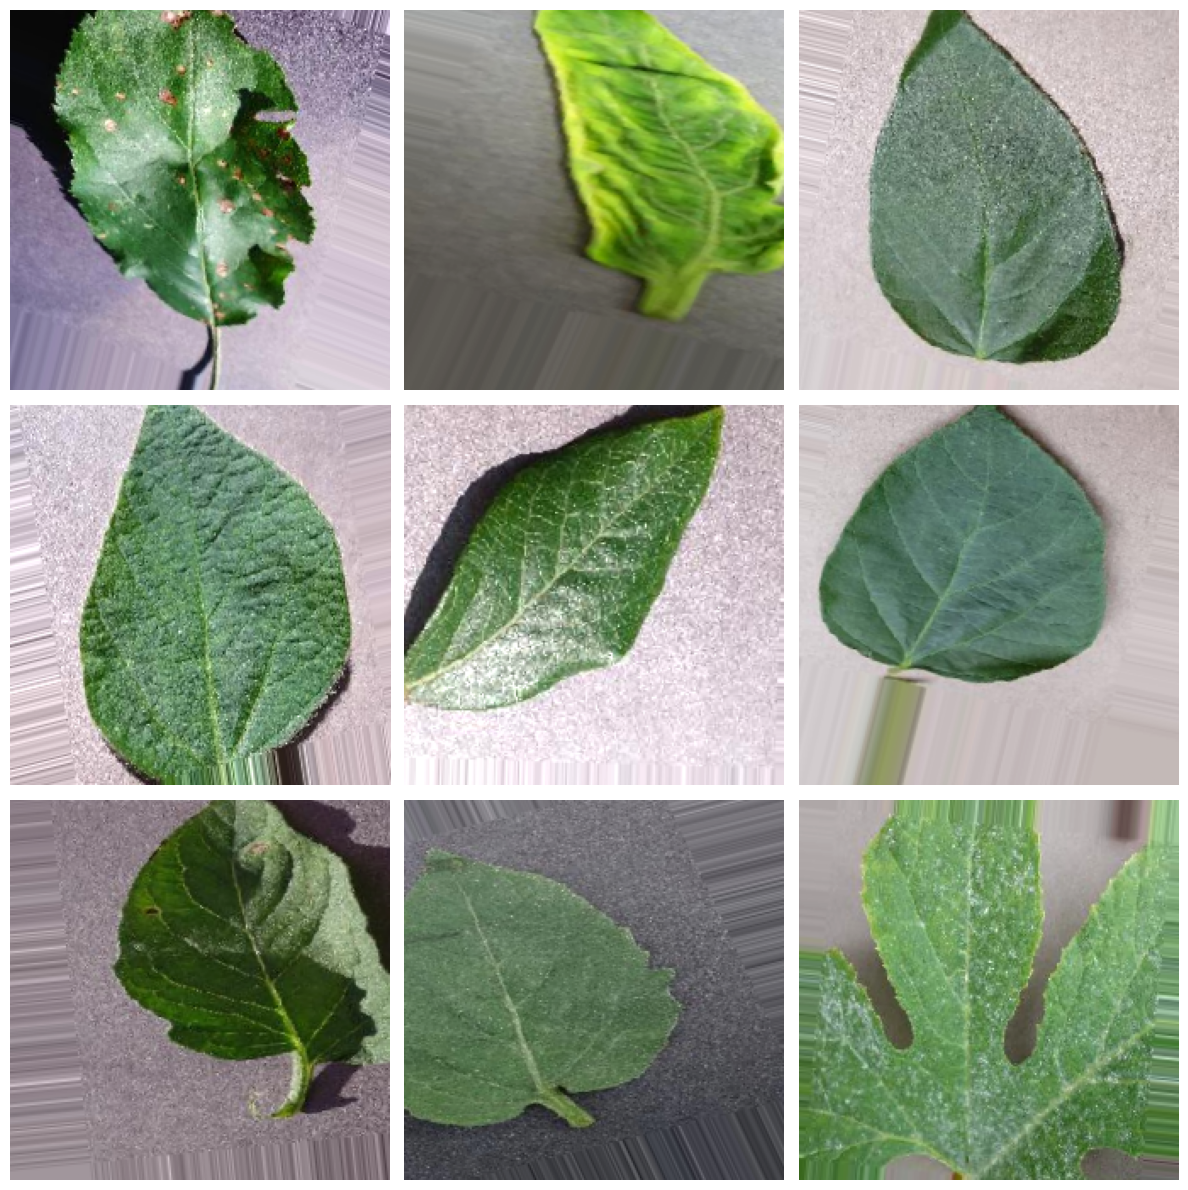

In [ ]:
plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

cnn_model = Sequential([

    # Block 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Block 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # GAP instead of Flatten
    GlobalAveragePooling2D(),

    # Dense Layers
    Dense(256, activation='relu'),
    Dropout(0.5),

    # Output
    Dense(38, activation='softmax')
])

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,934 (534.90 KB)

 Trainable params: 136,486 (533.15 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [ ]:
history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 643s 473ms/step - accuracy: 0.6446 - loss: 1.1805 - val_accuracy: 0.6085 - val_loss: 1.3504 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 623s 459ms/step - accuracy: 0.7968 - loss: 0.6489 - val_accuracy: 0.6751 - val_loss: 1.2578 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 621s 458ms/step - accuracy: 0.8528 - loss: 0.4628 - val_accuracy: 0.7066 - val_loss: 1.3878 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 618s 455ms/step - accuracy: 0.8856 - loss: 0.3650 - val_accuracy: 0.7046 - val_loss: 1.4304 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 621s 457ms/step - accuracy: 0.9051 - loss: 0.2973 - val_accuracy: 0.8340 - val_loss: 0.7610 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 628s 463ms/step - accuracy: 0.9176 - loss: 0.2517 - val_accuracy: 0.7736 - val_loss: 1.1072 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 614s 452ms

In [ ]:
cnn_model.save("baseline_cnn_model.h5")

print("Baseline CNN model saved.")

Baseline CNN model saved.


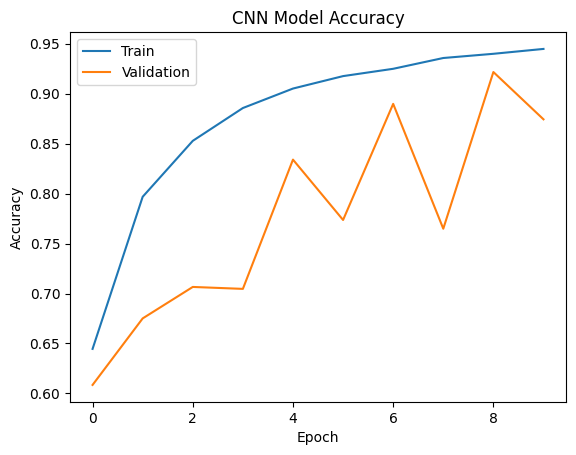

In [ ]:
plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

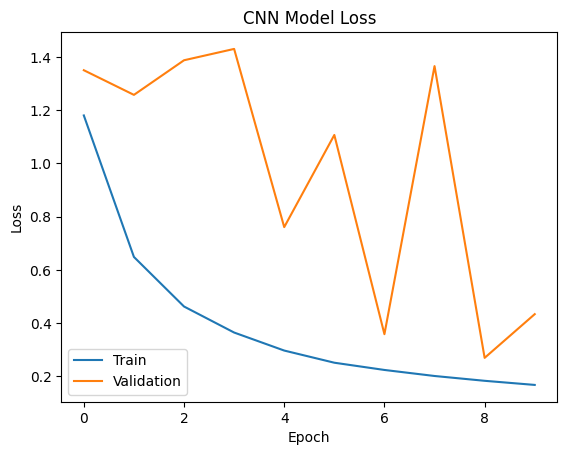

In [ ]:
plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

cnn_model = load_model("baseline_cnn_model.h5")

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

In [ ]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False

In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.5)(x)

predictions = Dense(38, activation='softmax')(x)

efficientnet_model = Model(
    inputs=base_model.input,
    outputs=predictions
)

In [ ]:
efficientnet_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,387,273 (16.74 MB)

 Trainable params: 337,702 (1.29 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 43444 images belonging to 38 classes.
Found 10861 images belonging to 38 classes.


In [ ]:
history_effnet = efficientnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 609s 448ms/step - accuracy: 0.8084 - loss: 0.6270 - val_accuracy: 0.9330 - val_loss: 0.2051 - learning_rate: 0.0010
Epoch 2/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 606s 446ms/step - accuracy: 0.8904 - loss: 0.3367 - val_accuracy: 0.9363 - val_loss: 0.1856 - learning_rate: 0.0010
Epoch 3/3
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 627s 462ms/step - accuracy: 0.9077 - loss: 0.2801 - val_accuracy: 0.9514 - val_loss: 0.1409 - learning_rate: 0.0010


In [ ]:
efficientnet_model.save("efficientnet_plant_disease.h5")

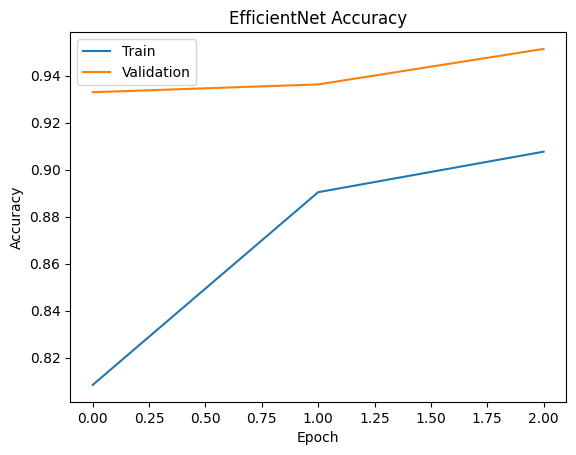

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history_effnet.history['accuracy'])
plt.plot(history_effnet.history['val_accuracy'])

plt.title("EfficientNet Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()

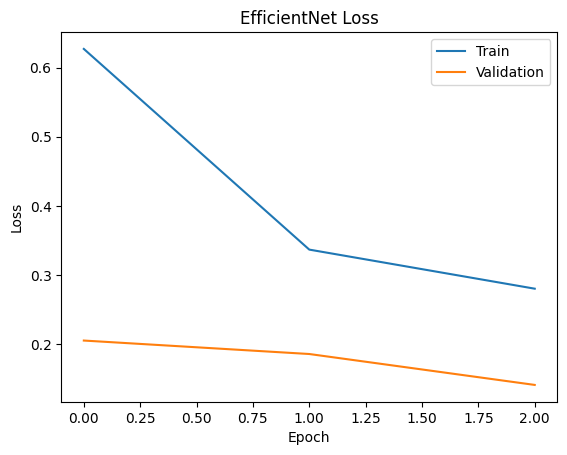

In [ ]:
plt.plot(history_effnet.history['loss'])
plt.plot(history_effnet.history['val_loss'])

plt.title("EfficientNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()